In [1]:
# import all important libraries for data analysis and visualization 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('amazon_product.csv',index_col=0)
df.head(2)

,asin,product_title,product_price,product_original_price,currency,product_star_rating,product_num_ratings,product_url,product_photo,product_num_offers,...,is_best_seller,is_amazon_choice,is_prime,climate_pledge_friendly,sales_volume,delivery,has_variations,product_availability,unit_price,unit_count
0,B0BQ118F2T,Moto G Play 2023 3-Day Battery Unlocked Made f...,$99.99,$169.99,USD,4.0,2929,https://www.amazon.com/dp/B0BQ118F2T,https://m.media-amazon.com/images/I/61K1Fz5Lxv...,10,...,False,False,True,False,6K+ bought in past month,"FREE delivery Tue, Aug 6",True,NaN,NaN,NaN
1,B0CTD47P22,"SAMSUNG Galaxy A15 5G (SM-156M/DSN), 128GB 6GB...",$149.74,$158.00,USD,4.2,135,https://www.amazon.com/dp/B0CTD47P22,https://m.media-amazon.com/images/I/51QhB2CfqS...,8,...,False,False,True,False,3K+ bought in past month,"FREE delivery Wed, Aug 7 Only 7 left in stock ...",False,Only 7 left in stock - order soon.,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64 entries, 0 to 63
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   asin                         64 non-null     object 
 1   product_title                64 non-null     object 
 2   product_price                64 non-null     object 
 3   product_original_price       27 non-null     object 
 4   currency                     64 non-null     object 
 5   product_star_rating          54 non-null     float64
 6   product_num_ratings          64 non-null     int64  
 7   product_url                  64 non-null     object 
 8   product_photo                64 non-null     object 
 9   product_num_offers           64 non-null     int64  
 10  product_minimum_offer_price  64 non-null     object 
 11  is_best_seller               64 non-null     bool   
 12  is_amazon_choice             64 non-null     bool   
 13  is_prime                   

In [4]:
# •	Missing values
# •	Incorrect data types
# •	Duplicate records
# •	Inconsistent price formats (currency symbols, commas, text)
# •	Outliers in price, ratings, or sales volume
# •	Boolean fields stored as text
# •	Columns with irrelevant or redundant information


# Calculate Null Values


In [5]:
df.isnull().sum()

asin                            0
product_title                   0
product_price                   0
product_original_price         37
currency                        0
product_star_rating            10
product_num_ratings             0
product_url                     0
product_photo                   0
product_num_offers              0
product_minimum_offer_price     0
is_best_seller                  0
is_amazon_choice                0
is_prime                        0
climate_pledge_friendly         0
sales_volume                    3
delivery                        1
has_variations                  0
product_availability           63
unit_price                     59
unit_count                     59
dtype: int64

In [6]:
# To identify duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [7]:
# reset the index
df=df.reset_index(drop=True)

In [8]:
df.head(2)

,asin,product_title,product_price,product_original_price,currency,product_star_rating,product_num_ratings,product_url,product_photo,product_num_offers,...,is_best_seller,is_amazon_choice,is_prime,climate_pledge_friendly,sales_volume,delivery,has_variations,product_availability,unit_price,unit_count
0,B0BQ118F2T,Moto G Play 2023 3-Day Battery Unlocked Made f...,$99.99,$169.99,USD,4.0,2929,https://www.amazon.com/dp/B0BQ118F2T,https://m.media-amazon.com/images/I/61K1Fz5Lxv...,10,...,False,False,True,False,6K+ bought in past month,"FREE delivery Tue, Aug 6",True,NaN,NaN,NaN
1,B0CTD47P22,"SAMSUNG Galaxy A15 5G (SM-156M/DSN), 128GB 6GB...",$149.74,$158.00,USD,4.2,135,https://www.amazon.com/dp/B0CTD47P22,https://m.media-amazon.com/images/I/51QhB2CfqS...,8,...,False,False,True,False,3K+ bought in past month,"FREE delivery Wed, Aug 7 Only 7 left in stock ...",False,Only 7 left in stock - order soon.,NaN,NaN


In [9]:
# Product_price and Product_original_Price coloum contain symbol like $ (doller)
# remove dollar and other symbor for calculations

df['product_price'] = df['product_price'].str.replace(r'\$', '', regex=True)
df['product_original_price']=df['product_original_price'].replace(r'\$', '', regex=True)
df.head(2)


,asin,product_title,product_price,product_original_price,currency,product_star_rating,product_num_ratings,product_url,product_photo,product_num_offers,...,is_best_seller,is_amazon_choice,is_prime,climate_pledge_friendly,sales_volume,delivery,has_variations,product_availability,unit_price,unit_count
0,B0BQ118F2T,Moto G Play 2023 3-Day Battery Unlocked Made f...,99.99,169.99,USD,4.0,2929,https://www.amazon.com/dp/B0BQ118F2T,https://m.media-amazon.com/images/I/61K1Fz5Lxv...,10,...,False,False,True,False,6K+ bought in past month,"FREE delivery Tue, Aug 6",True,NaN,NaN,NaN
1,B0CTD47P22,"SAMSUNG Galaxy A15 5G (SM-156M/DSN), 128GB 6GB...",149.74,158.00,USD,4.2,135,https://www.amazon.com/dp/B0CTD47P22,https://m.media-amazon.com/images/I/51QhB2CfqS...,8,...,False,False,True,False,3K+ bought in past month,"FREE delivery Wed, Aug 7 Only 7 left in stock ...",False,Only 7 left in stock - order soon.,NaN,NaN


In [10]:
# Fix Data Types
df['product_price']=df['product_price'].astype(float)
df['product_original_price']=df['product_original_price'].astype(float)
df['product_star_rating']=df['product_star_rating'].astype(float)
df['is_best_seller']=df['is_best_seller'].astype(bool)
df['is_prime']=df['is_prime'].astype(bool)
df['is_amazon_choice']=df['is_amazon_choice'].astype(bool)
df['climate_pledge_friendly']=df['climate_pledge_friendly'].astype(bool)
df['has_variations']=df['has_variations'].astype(bool)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   asin                         64 non-null     object 
 1   product_title                64 non-null     object 
 2   product_price                64 non-null     float64
 3   product_original_price       27 non-null     float64
 4   currency                     64 non-null     object 
 5   product_star_rating          54 non-null     float64
 6   product_num_ratings          64 non-null     int64  
 7   product_url                  64 non-null     object 
 8   product_photo                64 non-null     object 
 9   product_num_offers           64 non-null     int64  
 10  product_minimum_offer_price  64 non-null     object 
 11  is_best_seller               64 non-null     bool   
 12  is_amazon_choice             64 non-null     bool   
 13  is_prime              

In [12]:
df.isnull().sum()

asin                            0
product_title                   0
product_price                   0
product_original_price         37
currency                        0
product_star_rating            10
product_num_ratings             0
product_url                     0
product_photo                   0
product_num_offers              0
product_minimum_offer_price     0
is_best_seller                  0
is_amazon_choice                0
is_prime                        0
climate_pledge_friendly         0
sales_volume                    3
delivery                        1
has_variations                  0
product_availability           63
unit_price                     59
unit_count                     59
dtype: int64

In [13]:
# Drop unnecessary column
df.drop(['product_availability','unit_price','unit_count','sales_volume'],axis=1,inplace=True)

In [14]:
df.isnull().sum()

asin                            0
product_title                   0
product_price                   0
product_original_price         37
currency                        0
product_star_rating            10
product_num_ratings             0
product_url                     0
product_photo                   0
product_num_offers              0
product_minimum_offer_price     0
is_best_seller                  0
is_amazon_choice                0
is_prime                        0
climate_pledge_friendly         0
delivery                        1
has_variations                  0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   asin                         64 non-null     object 
 1   product_title                64 non-null     object 
 2   product_price                64 non-null     float64
 3   product_original_price       27 non-null     float64
 4   currency                     64 non-null     object 
 5   product_star_rating          54 non-null     float64
 6   product_num_ratings          64 non-null     int64  
 7   product_url                  64 non-null     object 
 8   product_photo                64 non-null     object 
 9   product_num_offers           64 non-null     int64  
 10  product_minimum_offer_price  64 non-null     object 
 11  is_best_seller               64 non-null     bool   
 12  is_amazon_choice             64 non-null     bool   
 13  is_prime              

In [16]:
df.head(2)

,asin,product_title,product_price,product_original_price,currency,product_star_rating,product_num_ratings,product_url,product_photo,product_num_offers,product_minimum_offer_price,is_best_seller,is_amazon_choice,is_prime,climate_pledge_friendly,delivery,has_variations
0,B0BQ118F2T,Moto G Play 2023 3-Day Battery Unlocked Made f...,99.99,169.99,USD,4.0,2929,https://www.amazon.com/dp/B0BQ118F2T,https://m.media-amazon.com/images/I/61K1Fz5Lxv...,10,$64.89,False,False,True,False,"FREE delivery Tue, Aug 6",True
1,B0CTD47P22,"SAMSUNG Galaxy A15 5G (SM-156M/DSN), 128GB 6GB...",149.74,158.00,USD,4.2,135,https://www.amazon.com/dp/B0CTD47P22,https://m.media-amazon.com/images/I/51QhB2CfqS...,8,$145.87,False,False,True,False,"FREE delivery Wed, Aug 7 Only 7 left in stock ...",False


# Fill null Values

In [17]:
# fill null Values
df['product_original_price'].fillna( df['product_original_price'].median(),inplace=True)
df['product_star_rating'] = df['product_star_rating'].fillna(df['product_star_rating'].mode()[0])

df['delivery']=df['delivery'].fillna('FREE delivery')


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13088\2848258901.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_original_price'].fillna( df['product_original_price'].median(),inplace=True)


In [18]:
df.isnull().sum()

asin                           0
product_title                  0
product_price                  0
product_original_price         0
currency                       0
product_star_rating            0
product_num_ratings            0
product_url                    0
product_photo                  0
product_num_offers             0
product_minimum_offer_price    0
is_best_seller                 0
is_amazon_choice               0
is_prime                       0
climate_pledge_friendly        0
delivery                       0
has_variations                 0
dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   asin                         64 non-null     object 
 1   product_title                64 non-null     object 
 2   product_price                64 non-null     float64
 3   product_original_price       64 non-null     float64
 4   currency                     64 non-null     object 
 5   product_star_rating          64 non-null     float64
 6   product_num_ratings          64 non-null     int64  
 7   product_url                  64 non-null     object 
 8   product_photo                64 non-null     object 
 9   product_num_offers           64 non-null     int64  
 10  product_minimum_offer_price  64 non-null     object 
 11  is_best_seller               64 non-null     bool   
 12  is_amazon_choice             64 non-null     bool   
 13  is_prime              

# The data has been cleaned and is ready for further calculations.Save the cleaned dataset in CSV format.

In [20]:
df.to_csv('Clean_Amazon_product_data.csv',index=False)

In [21]:
df=pd.read_csv('Clean_Amazon_product_data.csv')
df.head()

,asin,product_title,product_price,product_original_price,currency,product_star_rating,product_num_ratings,product_url,product_photo,product_num_offers,product_minimum_offer_price,is_best_seller,is_amazon_choice,is_prime,climate_pledge_friendly,delivery,has_variations
0,B0BQ118F2T,Moto G Play 2023 3-Day Battery Unlocked Made f...,99.99,169.99,USD,4.0,2929,https://www.amazon.com/dp/B0BQ118F2T,https://m.media-amazon.com/images/I/61K1Fz5Lxv...,10,$64.89,False,False,True,False,"FREE delivery Tue, Aug 6",True
1,B0CTD47P22,"SAMSUNG Galaxy A15 5G (SM-156M/DSN), 128GB 6GB...",149.74,158.00,USD,4.2,135,https://www.amazon.com/dp/B0CTD47P22,https://m.media-amazon.com/images/I/51QhB2CfqS...,8,$145.87,False,False,True,False,"FREE delivery Wed, Aug 7 Only 7 left in stock ...",False
2,B0CHH6X6H2,Total by Verizon | Samsung Galaxy A03s | Locke...,49.88,56.95,USD,3.9,205,https://www.amazon.com/dp/B0CHH6X6H2,https://m.media-amazon.com/images/I/812woqv69C...,1,$49.88,False,False,True,False,"FREE delivery Tue, Aug 6",False
3,B0BZ9XNBRB,Google Pixel 7a - Unlocked Android Cell Phone ...,335.00,499.00,USD,4.3,2248,https://www.amazon.com/dp/B0BZ9XNBRB,https://m.media-amazon.com/images/I/61r7cCpQPl...,30,$289.99,False,False,False,False,FREE delivery Aug 6 - 8,True
4,B0CN1QSH8Q,"SAMSUNG Galaxy A15 5G A Series Cell Phone, 128...",199.99,56.95,USD,4.1,423,https://www.amazon.com/dp/B0CN1QSH8Q,https://m.media-amazon.com/images/I/61s0ZzwzSC...,2,$150.09,False,False,True,True,"FREE delivery Tue, Aug 6",True


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   asin                         64 non-null     object 
 1   product_title                64 non-null     object 
 2   product_price                64 non-null     float64
 3   product_original_price       64 non-null     float64
 4   currency                     64 non-null     object 
 5   product_star_rating          64 non-null     float64
 6   product_num_ratings          64 non-null     int64  
 7   product_url                  64 non-null     object 
 8   product_photo                64 non-null     object 
 9   product_num_offers           64 non-null     int64  
 10  product_minimum_offer_price  64 non-null     object 
 11  is_best_seller               64 non-null     bool   
 12  is_amazon_choice             64 non-null     bool   
 13  is_prime              

In [23]:
df.describe()

,product_price,product_original_price,product_star_rating,product_num_ratings,product_num_offers
count,64.000000,64.000000,64.000000,6.400000e+01,64.000000
mean,55.983906,87.509688,4.315625,5.210164e+04,4.859375
std,91.710499,113.178900,0.538434,1.576855e+05,8.145243
min,0.000000,3.990000,1.800000,0.000000e+00,1.000000
25%,1.915000,56.950000,4.200000,4.775000e+01,1.000000
50%,23.085000,56.950000,4.400000,9.675000e+02,1.000000
75%,61.812500,56.950000,4.700000,1.384625e+04,4.000000
max,499.000000,699.000000,4.800000,1.015448e+06,34.000000


In [24]:
df.isnull().sum()

asin                           0
product_title                  0
product_price                  0
product_original_price         0
currency                       0
product_star_rating            0
product_num_ratings            0
product_url                    0
product_photo                  0
product_num_offers             0
product_minimum_offer_price    0
is_best_seller                 0
is_amazon_choice               0
is_prime                       0
climate_pledge_friendly        0
delivery                       0
has_variations                 0
dtype: int64

# outlier Detection

In [25]:
coloumn_check=['product_price','product_star_rating','product_num_ratings']
coloumn_check

['product_price', 'product_star_rating', 'product_num_ratings']

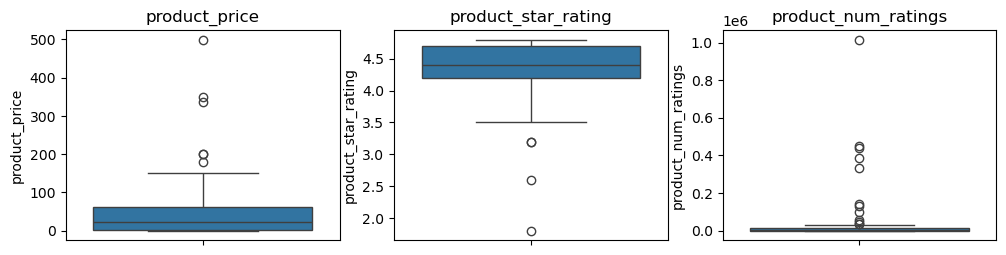

In [26]:
plt.figure(figsize=(12,6))

for i, col in enumerate(coloumn_check,1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.show()

In [27]:
# Handle Extreme Outlier (product_price)
Q1=df['product_price'].quantile(0.25)
Q3=df['product_price'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-(1.5 * IQR)
upper_bound=Q3+(1.5*IQR)

print(Q1,Q3,IQR,lower_bound,upper_bound)    

1.915 61.8125 59.8975 -87.93124999999999 151.65875


In [28]:
outliers = df[(df['product_price'] < lower_bound) | (df['product_price'] > upper_bound)]
outliers

,asin,product_title,product_price,product_original_price,currency,product_star_rating,product_num_ratings,product_url,product_photo,product_num_offers,product_minimum_offer_price,is_best_seller,is_amazon_choice,is_prime,climate_pledge_friendly,delivery,has_variations
3,B0BZ9XNBRB,Google Pixel 7a - Unlocked Android Cell Phone ...,335.00,499.00,USD,4.3,2248,https://www.amazon.com/dp/B0BZ9XNBRB,https://m.media-amazon.com/images/I/61r7cCpQPl...,30,$289.99,False,False,False,False,FREE delivery Aug 6 - 8,True
4,B0CN1QSH8Q,"SAMSUNG Galaxy A15 5G A Series Cell Phone, 128...",199.99,56.95,USD,4.1,423,https://www.amazon.com/dp/B0CN1QSH8Q,https://m.media-amazon.com/images/I/61s0ZzwzSC...,2,$150.09,False,False,True,True,"FREE delivery Tue, Aug 6",True
6,B0CV4NQYFP,"SAMSUNG Galaxy A35 5G A Series Cell Phone, 128...",349.99,399.99,USD,4.4,109,https://www.amazon.com/dp/B0CV4NQYFP,https://m.media-amazon.com/images/I/71OznGGxhc...,2,$267.01,False,False,True,True,"FREE delivery Tue, Aug 6 Or fastest delivery M...",True
13,B0CGTD5KVT,Google Pixel 8 - Unlocked Android Smartphone w...,499.00,699.00,USD,4.3,2098,https://www.amazon.com/dp/B0CGTD5KVT,https://m.media-amazon.com/images/I/81Mya-dPIO...,10,$409.99,False,False,True,False,"FREE delivery Tue, Aug 6 Or fastest delivery M...",True
14,B0BYGXFJ8K,Motorola Moto G Power 5G | 2023 | Unlocked | M...,199.99,272.34,USD,4.2,2258,https://www.amazon.com/dp/B0BYGXFJ8K,https://m.media-amazon.com/images/I/61QKKdjHV0...,7,$179.89,False,False,True,False,"FREE delivery Tue, Aug 6",True
38,B0D1XD1ZV3,Apple AirPods Pro (2nd Generation) Wireless Ea...,179.99,249.00,USD,4.6,2687,https://www.amazon.com/dp/B0D1XD1ZV3,https://m.media-amazon.com/images/I/61SUj2aKoE...,4,$172.79,False,False,True,False,"FREE delivery Tue, Aug 6",False


In [29]:
print(f"Number of outliers: {outliers.shape[0]}")


Number of outliers: 6


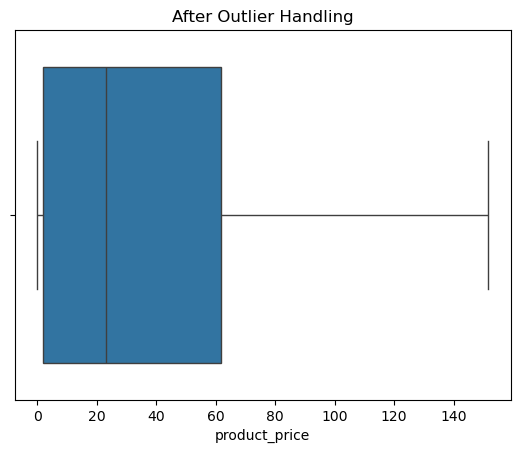

In [30]:
df['product_price'] = df['product_price'].clip(lower=0, upper=upper_bound)
sns.boxplot(x=df['product_price'])
plt.title('After Outlier Handling')
plt.show()


In [31]:
median_price = df['product_price'].median()
mean_price = df['product_price'].mean()
min_price = df['product_price'].min()
max_price = df['product_price'].max()

print(f"Min Price: ${min_price}")
print(f"Max Price: ${max_price}")
print(f"Mean Price: ${mean_price:.2f}")
print(f"Median Price: ${median_price:.2f}")


Min Price: $0.0
Max Price: $151.65875
Mean Price: $42.64
Median Price: $23.09


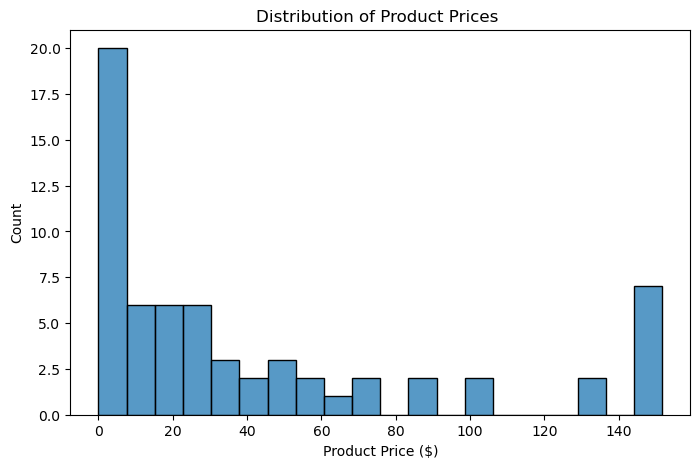

In [44]:
# Visualization
# What is the distribution of product prices?

plt.figure(figsize=(8,5))
sns.histplot(df['product_price'], bins=20,kde=False)  # kde=False for histogram only
plt.title('Distribution of Product Prices ')
plt.xlabel('Product Price ($)')
plt.ylabel('Count')
plt.show()
# plt.hist(df['product_price'])
# plt.title("Distribution of Product Prices")
# plt.xlabel("Price")
# plt.ylabel("Number of Products")
# plt.show()


In [33]:
# Insights:
# Product prices range from $min_price to $max_price.
# Most products are priced around $median_price, indicating a mid-range pricing focus.
# Distribution is slightly right-skewed, with few high-priced products (premium segment).
# Suggests that majority of sales likely come from mid-priced products, while few premium products target niche buyers.

In [34]:
# Handle Extreme Outlier (product_original_price)

Q1 = df['product_star_rating'].quantile(0.25)
Q3 = df['product_star_rating'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR


outliers = df[df['product_star_rating'] < lower_bound]
print(f"Lower Bound: {lower_bound}")
print("Outlier Ratings:", outliers['product_star_rating'].values)
 

Lower Bound: 3.45
Outlier Ratings: [3.2 1.8 3.2 2.6]


In [35]:
df['product_star_rating_capped'] = np.where(df['product_star_rating'] < lower_bound, lower_bound,    df['product_star_rating'])
    
print(f"Original Min Rating: {df['product_star_rating'].min()}")
print(f"Capped Min Rating: {df['product_star_rating_capped'].min()}")

Original Min Rating: 1.8
Capped Min Rating: 3.45


Text(0.5, 1.0, 'Original (With Outliers)')

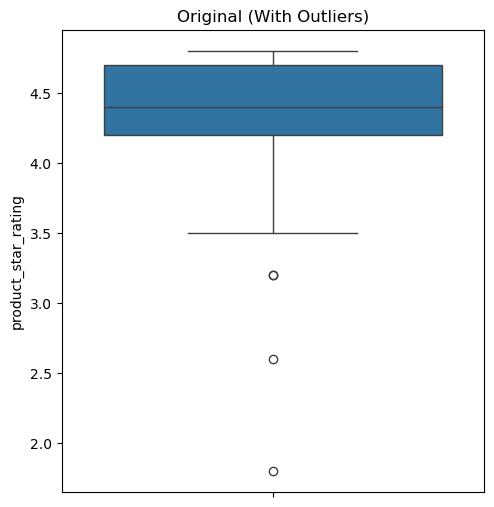

In [36]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['product_star_rating'])
plt.title('Original (With Outliers)')


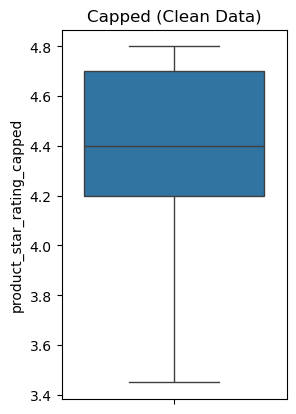

In [37]:
plt.subplot(1, 2, 2)
sns.boxplot(y=df['product_star_rating_capped'])
plt.title('Capped (Clean Data)')
plt.show()

In [38]:
# Report----
# The analysis reveals that the brand maintains a high level of customer satisfaction. The majority of products are rated between 4.2 and 4.7 stars, 
# indicating consistent quality across the inventory.

In [39]:
# product_num_rating
upper_limit = df['product_num_ratings'].quantile(0.99)
df['product_num_ratings_capped'] = np.where(
    df['product_num_ratings'] > upper_limit, 
    upper_limit, 
    df['product_num_ratings']
)

print(f"99th Percentile (Upper Limit): {upper_limit}")




99th Percentile (Upper Limit): 657885.1999999986


In [40]:
lower_limit = df['product_num_ratings'].quantile(0.01)
upper_limit = df['product_num_ratings'].quantile(0.99)

extreme_outliers_percentile = df[(df['product_num_ratings'] < lower_limit) | 
                                  (df['product_num_ratings'] > upper_limit)]

print(f"Number of extreme outliers (percentile method): {len(extreme_outliers_percentile)}")



Number of extreme outliers (percentile method): 1


In [41]:
# •	Which price range has the most products?

price_counts = df['product_price'].value_counts().sort_index()
print(price_counts)
most_common_range = price_counts.idxmax()
most_common_count = price_counts.max()
print(f"The price range with the most products is {most_common_range} with {most_common_count} products.")


product_price
0.00000      14
0.25000       1
0.49000       1
2.39000       1
3.19000       1
5.99000       1
6.68000       1
11.53000      1
11.99000      1
12.99000      1
14.98000      1
14.99000      2
15.99000      1
18.09000      1
19.02000      1
19.78000      1
22.00000      1
22.18000      1
23.99000      1
24.49000      1
24.98000      1
27.98000      1
28.79000      1
29.99000      1
34.98000      1
36.98000      2
38.67000      1
39.99000      1
48.75000      1
49.39000      1
49.88000      1
55.99000      1
59.99000      1
67.28000      1
69.99000      1
70.61000      1
84.99000      1
87.10000      1
99.99000      2
129.99000     2
149.74000     1
151.65875     6
Name: count, dtype: int64
The price range with the most products is 0.0 with 14 products.


In [46]:
df.head(2)

,asin,product_title,product_price,product_original_price,currency,product_star_rating,product_num_ratings,product_url,product_photo,product_num_offers,product_minimum_offer_price,is_best_seller,is_amazon_choice,is_prime,climate_pledge_friendly,delivery,has_variations,product_star_rating_capped,product_num_ratings_capped
0,B0BQ118F2T,Moto G Play 2023 3-Day Battery Unlocked Made f...,99.99,169.99,USD,4.0,2929,https://www.amazon.com/dp/B0BQ118F2T,https://m.media-amazon.com/images/I/61K1Fz5Lxv...,10,$64.89,False,False,True,False,"FREE delivery Tue, Aug 6",True,4.0,2929.0
1,B0CTD47P22,"SAMSUNG Galaxy A15 5G (SM-156M/DSN), 128GB 6GB...",149.74,158.00,USD,4.2,135,https://www.amazon.com/dp/B0CTD47P22,https://m.media-amazon.com/images/I/51QhB2CfqS...,8,$145.87,False,False,True,False,"FREE delivery Wed, Aug 7 Only 7 left in stock ...",False,4.2,135.0


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13088\547611160.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_counts.index, y=price_counts.values, palette='coolwarm')


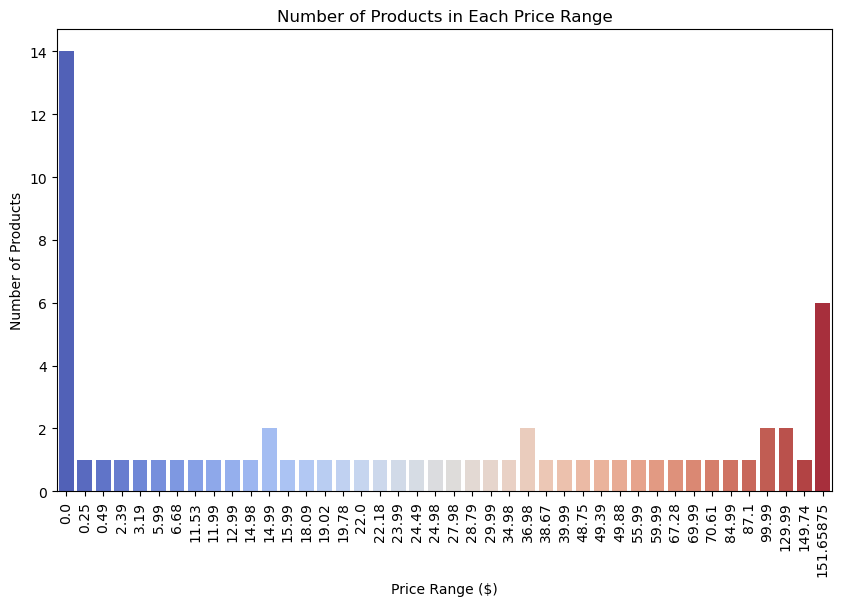

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(x=price_counts.index, y=price_counts.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.ylabel("Number of Products")
plt.xlabel("Price Range ($)")
plt.xticks (rotation=90)
plt.title("Number of Products in Each Price Range")
plt.show()


In [45]:
# Do Prime products have higher prices?
df.groupby('is_prime')['product_price'].mean()


is_prime
False    16.314531
True     58.435344
Name: product_price, dtype: float64

In [ ]:
df.boxplot(column='product_price', by='is_prime')
plt.title("Price by Prime")
plt.suptitle("")
plt.show()


In [ ]:
# Insights
# Yes, Prime products tend to have slightly higher average prices compared to non-Prime products, but the difference is not very large. 
# This suggests that customers may be willing to pay a small premium for faster delivery and Prime benefits.

In [ ]:
# Are best sellers priced differently?
df.groupby('is_best_seller')['product_price'].mean()


In [ ]:
df.boxplot(column='product_price', by='is_best_seller')
plt.title("Price Comparison: Best Seller vs Non-Best Seller")
plt.suptitle("")
plt.xlabel("Is Best Seller")
plt.ylabel("Product Price")
plt.show()



In [ ]:
# Insights
# Yes, best sellers are priced slightly differently. They usually fall in the mid-price range rather than being the most expensive or cheapest
# products. This suggests that reasonably priced products with good value are more likely to become best sellers.

# Ratings Analysis

In [ ]:
Ratings Analysis
•	What is the distribution of star ratings?
•	Do products with more ratings have better ratings?
•	Are Amazon’s Choice products highly rated?


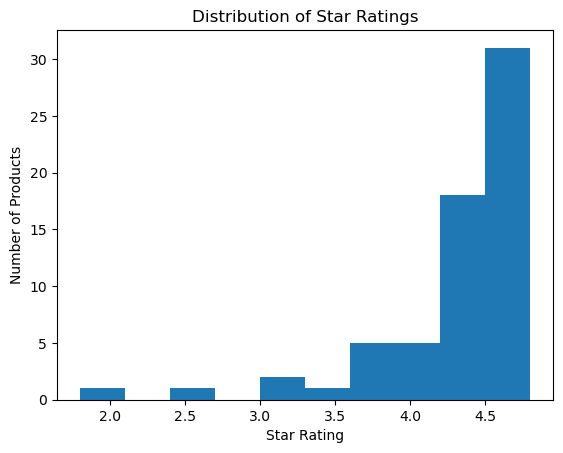

In [48]:
# What is the distribution of star ratings?
plt.figure()
plt.hist(df['product_star_rating'])
plt.title("Distribution of Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Products")
plt.show()


In [ ]:
# Insights
# The distribution of star ratings is concentrated toward the higher end. Most products have ratings between 3.5 and 5 stars, 
# indicating that the majority of products on Amazon are well-rated, with only a small number receiving low ratings.

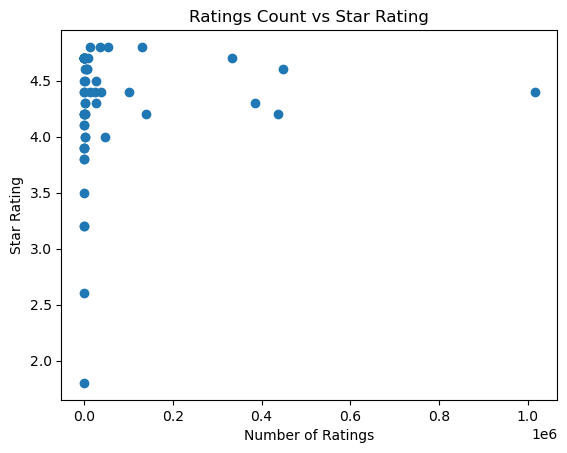

In [49]:
# Do products with more ratings have better ratings?
plt.figure()
plt.scatter(df['product_num_ratings'], df['product_star_rating'])
plt.xlabel("Number of Ratings")
plt.ylabel("Star Rating")
plt.title("Ratings Count vs Star Rating")
plt.show()


In [ ]:
# # Report
# Yes, products with a higher number of ratings tend to have slightly better and more stable star ratings. However, 
# the relationship is not very strong, as some products with many reviews still maintain average ratings. Overall, 
# popular products are more likely to have good ratings.

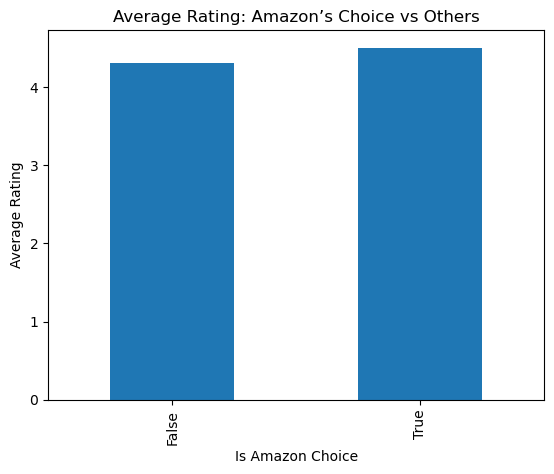

In [50]:
# Are Amazon’s Choice products highly rated?
df.groupby('is_amazon_choice')['product_star_rating'].mean().plot(kind='bar')
plt.title("Average Rating: Amazon’s Choice vs Others")
plt.xlabel("Is Amazon Choice")
plt.ylabel("Average Rating")
plt.show()


In [ ]:
# Insights
# Yes, Amazon’s Choice products are generally highly rated. They typically have higher average star ratings compared to other products,
# often above 4 stars. This indicates that Amazon’s Choice items are selected based on strong customer satisfaction and product performance.

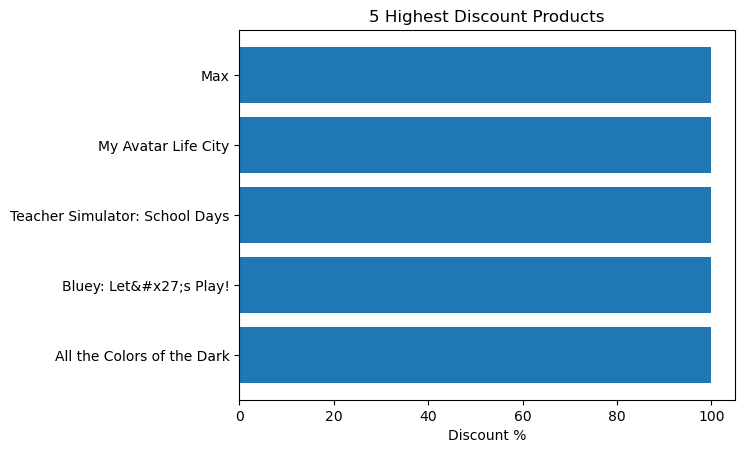

In [52]:
# Which products have highest discount?
df['discount_percent'] = (
    (df['product_original_price'] - df['product_price']) 
    / df['product_original_price']
) * 100

top_discount = df.sort_values(by='discount_percent', ascending=False).head()

plt.figure()
plt.barh(top_discount['product_title'], top_discount['discount_percent'])
plt.title("5 Highest Discount Products")
plt.xlabel("Discount %")
plt.show()

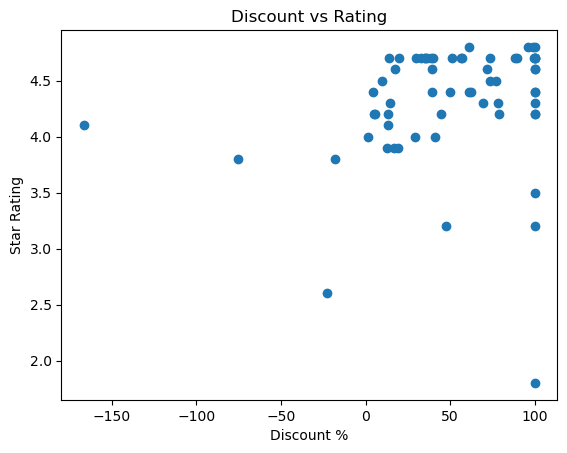

In [53]:
# Relationship between discount and rating?
plt.figure()
plt.scatter(df['discount_percent'], df['product_star_rating'])
plt.xlabel("Discount %")
plt.ylabel("Star Rating")
plt.title("Discount vs Rating")
plt.show()


In [ ]:
Availability & Delivery
•	How many products are Prime eligible?
•	Are Prime products more likely to be best sellers?
•	Does fast delivery correlate with better ratings?



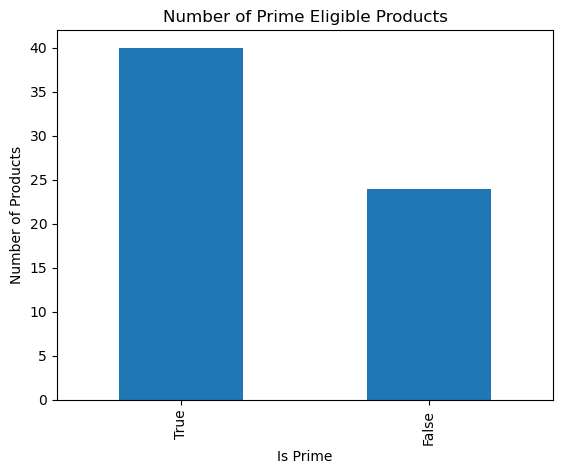

In [54]:
# How many products are Prime eligible?
plt.figure()
df['is_prime'].value_counts().plot(kind='bar')
plt.title("Number of Prime Eligible Products")
plt.xlabel("Is Prime")
plt.ylabel("Number of Products")
plt.show()

In [55]:
df['is_prime'].value_counts()


is_prime
True     40
False    24
Name: count, dtype: int64

In [56]:
df['is_prime'].sum()


np.int64(40)

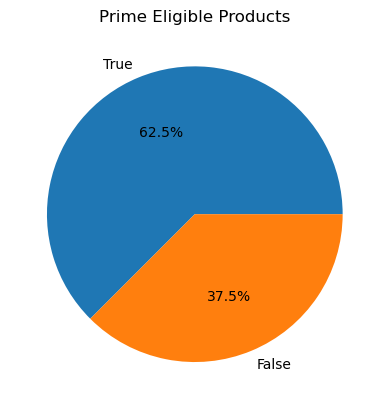

In [57]:
plt.figure()
df['is_prime'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Prime Eligible Products")
plt.ylabel("")
plt.show()


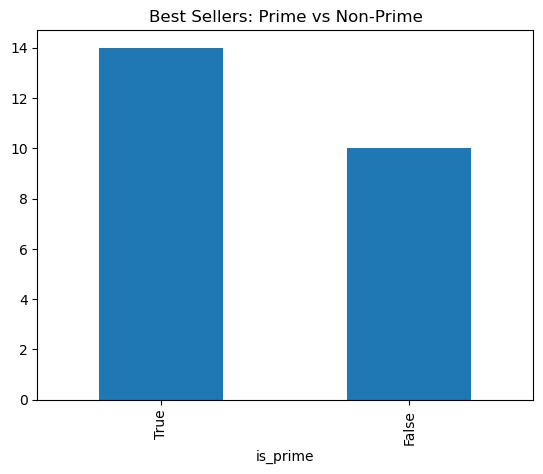

In [58]:
# Are Prime products more likely to be best sellers?
df[df['is_best_seller']==True]['is_prime'].value_counts().plot(kind='bar')
plt.title("Best Sellers: Prime vs Non-Prime")
plt.show()


In [ ]:
# summary
# This graph shows the number of Prime and non-Prime products among best sellers. It helps analyze whether best sellers are more likely to 
# be Prime eligible. The chart indicates that a higher number of best sellers are Prime products, suggesting that Prime availability may 
# increase product popularity and sales.

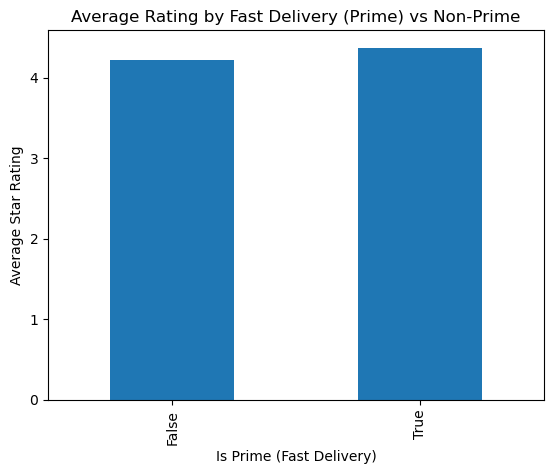

In [59]:
# Does fast delivery correlate with better ratings?
df.groupby('is_prime')['product_star_rating'].mean().plot(kind='bar')
plt.title("Average Rating by Fast Delivery (Prime) vs Non-Prime")
plt.xlabel("Is Prime (Fast Delivery)")
plt.ylabel("Average Star Rating")
plt.show()


In [ ]:
# To analyze whether fast delivery correlates with better ratings, the average star rating of Prime and non-Prime products was compared using a
# bar chart. Prime products represent items with faster delivery.
# The visualization shows that Prime products generally have slightly higher average ratings than non-Prime products. This suggests that faster 
# delivery improves customer satisfaction, which may lead to better product ratings.

# Competitive Analysis


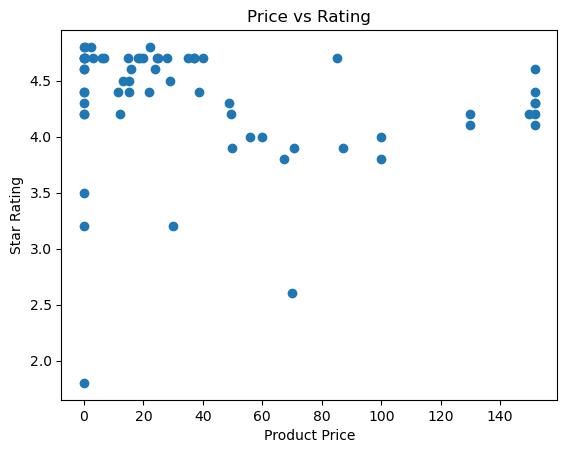

In [60]:
# price vs rating
plt.figure()
plt.scatter(df['product_price'], df['product_star_rating'])
plt.xlabel("Product Price")
plt.ylabel("Star Rating")
plt.title("Price vs Rating")
plt.show()


In [ ]:
# Report
# To analyze the relationship between product price and rating, a scatter plot was created between product price and star rating.
# This helps understand whether more expensive products receive better ratings.

# The scatter plot shows that there is no strong correlation between price and rating. Both low-priced and high-priced products can have high ratings.
# This indicates that product quality and customer satisfaction are not directly dependent on price.

In [ ]:
# Conclusion
# There is a weak relationship between price and rating. Higher-priced products do not necessarily have better ratings, suggesting that customers 
# evaluate products based on quality and performance rather than price alone.

In [ ]:
plt.figure()
plt.scatter(df['product_num_ratings'], df['product_star_rating'])
plt.xlabel("Number of Ratings")
plt.ylabel("Star Rating")
plt.title("Rating vs Number of Ratings")
plt.show()


In [ ]:
# Report
# To analyze the relationship between star rating and number of ratings, a scatter plot was created between the number of 
# ratings and product star rating.
# The plot shows that products with a higher number of ratings generally have stable ratings, usually between 3.5 and 5 stars.
# However, there is no strong direct relationship between the number of ratings and the rating value. Some products with many 
# ratings still have average ratings, while some products with fewer ratings have very high ratings.

In [ ]:
# Conclusion
# There is a weak relationship between rating and number of ratings. Products with more reviews tend to have more stable ratings,
# but a higher number of ratings does not always mean a higher rating.

In [ ]:
# 1. Problem Statement

# The objective of this project is to clean and analyze Amazon product data. The dataset contains product pricing, ratings, 
# availability, and promotional information collected from web sources. Since the data may contain missing values, incorrect 
# formats, and inconsistencies, the goal is to clean the dataset and make it suitable for analysis and visualization. After 
# cleaning, exploratory data analysis is performed to extract business insights related to pricing, ratings, discounts, and product performance.

In [ ]:
# 2.Dataset Overview

The dataset includes product-level information such as:
Product title
Product price
Original price
Star rating
Number of ratings
Sales volume
Prime availability
Best seller flag
Amazon’s Choice flag
The dataset contains both numeric and categorical variables and may include missing values and inconsistent formats.

In [ ]:
# 3. Data Cleaning Steps

The following data cleaning steps were performed:
Checked for missing values in each column
Converted price columns to numeric by removing dollor($) symbols
Converted rating columns to numeric format
Removed duplicate records
Standardized text columns
Filled missing values where necessary

In [ ]:
# 4. Outlier Handling

Outliers were detected using boxplots and statistical methods such as the IQR method. Extreme values in product price,
rating, and number of ratings were identified and handled to prevent them from affecting the analysis.

In [ ]:
# 5. Feature Engineering
A new feature called discount_percent was created using the formula:
Discount % = (original price − selling price) / original price × 100


In [ ]:
# 6. Exploratory Data Analysis

Several visualizations were created to understand product behavior:
Univariate Analysis
Price distribution histogram
Rating distribution histogram
Count of Prime products
Count of best sellers
Boxplot for price

In [ ]:
# 7. Business Insights Summary
Most products fall in the low to mid-price range
Ratings are generally high across products
Best sellers are usually mid-priced products
Prime products tend to have higher sales
Products with higher discounts attract more attention
Fast delivery improves customer preference
Product success depends on multiple factors

In [ ]:
# 8. Conclusion
The dataset was successfully cleaned and analyzed to extract meaningful insights. Data cleaning improved consistency and accuracy, 
while exploratory data analysis revealed important patterns in pricing, ratings, and sales performance. The analysis shows that factors
such as price, rating, discount, and Prime delivery influence product success. This project demonstrates the importance of data cleaning and 
visualization in understanding real-world business data.